# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

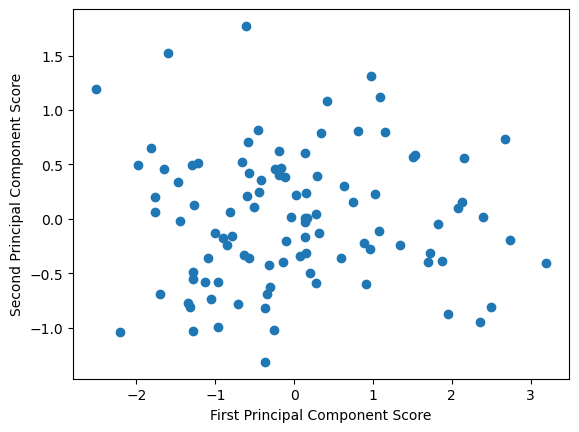

In [2]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

### Graph Question Answer

The three outliers in the upper left have a **low first principal component score** and a **high second principal component score**.

**First PC score (low):** The first principal component captures the overall shared magnitude of all three series. Since all three are derived from `series_1`, they are all positively correlated — they tend to move together. A low first PC score means that for those data points, all three series values are below average.

**Second PC score (high):** The second principal component primarily captures how much `series_3` deviates from what `series_1` and `series_2` would predict. Since `series_3 = series_1 * (1 + N(0, 0.5))` — with noise scale 0.5 — it can stray far from `series_1`. A high second PC score means `series_3` is relatively high compared to what the first PC predicts.

So we can say something clear about **series_3**: for these outliers, series_3 is relatively elevated compared to series_1 and series_2.

**Why is it hard to say anything about series_1 vs. series_2?** Because `series_2 = series_1 * (1 + N(0, 0.1))` — they are nearly identical (correlation ≈ 1). In the PCA components, series_1 and series_2 will have nearly equal weights. Knowing the PC scores tells us they are both below average, but gives us almost no information about which one is higher relative to the other. A pairplot of the three series would show series_1 vs series_2 as an almost-perfect line, confirming they are nearly indistinguishable.

**Advantages of this graph:** It compresses three dimensions into two, making it easy to spot outliers and overall data structure at a glance.

**Disadvantages:** Interpretability is lost — it is hard to link back to specific values of `series_1`, `series_2`, or `series_3` without knowing the component vectors. The axes are not intuitive. If the first two PCs explain only part of the variance, important structure is hidden.

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import decomposition, linear_model, metrics

# Load the ACS 2015 county-level dataset
df = pd.read_csv("acs2015_county_data.csv")

# Select the key socioeconomic features relevant to the diabetes prevalence project
features = ["Income", "IncomePerCap", "Poverty", "ChildPoverty", "Unemployment", "Professional"]
df_feat = df[features].dropna()

print(df_feat.shape)
df_feat.describe()

(3218, 6)


,Income,IncomePerCap,Poverty,ChildPoverty,Unemployment,Professional
count,3218.000000,3218.000000,3218.000000,3218.000000,3218.000000,3218.000000
mean,46123.616532,23974.101616,17.490429,24.188316,8.094779,30.993132
std,12908.429676,6193.155892,8.317939,11.692375,4.093038,6.368637
min,10499.000000,5878.000000,1.400000,0.000000,0.000000,13.500000
25%,38191.250000,20235.500000,12.100000,16.300000,5.500000,26.700000
50%,44748.500000,23457.500000,16.150000,22.700000,7.600000,29.900000
75%,52059.000000,27051.000000,20.700000,30.000000,9.900000,34.400000
max,123453.000000,65600.000000,64.200000,81.600000,36.500000,74.000000


### Heatmap

We discretize Income and Poverty into quintiles and create a heatmap showing the average unemployment rate in each income/poverty combination. This reveals how unemployment is distributed across the joint income-poverty space.

/var/folders/hb/x2mhw6jn7x35b5xw13m920y00000gn/T/ipykernel_13246/1522849143.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df_heat.pivot_table(index="Poverty_quintile", columns="Income_quintile", values="Unemployment", aggfunc="mean")


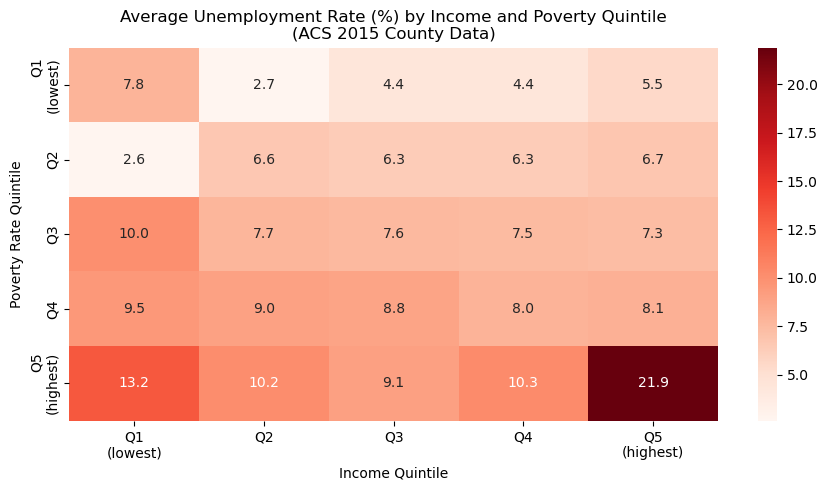

In [4]:
df_heat = df_feat.copy()
df_heat["Income_quintile"] = pd.qcut(df_heat["Income"], 5, labels=["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])
df_heat["Poverty_quintile"] = pd.qcut(df_heat["Poverty"], 5, labels=["Q1\n(lowest)", "Q2", "Q3", "Q4", "Q5\n(highest)"])

pivot = df_heat.pivot_table(index="Poverty_quintile", columns="Income_quintile", values="Unemployment", aggfunc="mean")

plt.figure(figsize=(9, 5))
ax = sns.heatmap(pivot, cmap="Reds", annot=True, fmt=".1f")
ax.set_title("Average Unemployment Rate (%) by Income and Poverty Quintile\n(ACS 2015 County Data)")
ax.set_xlabel("Income Quintile")
ax.set_ylabel("Poverty Rate Quintile")
plt.tight_layout()
plt.show()

### Bubble Plot

We plot Income vs. Poverty rate, with the bubble size representing the unemployment rate. This lets us see three socioeconomic variables at once across counties.

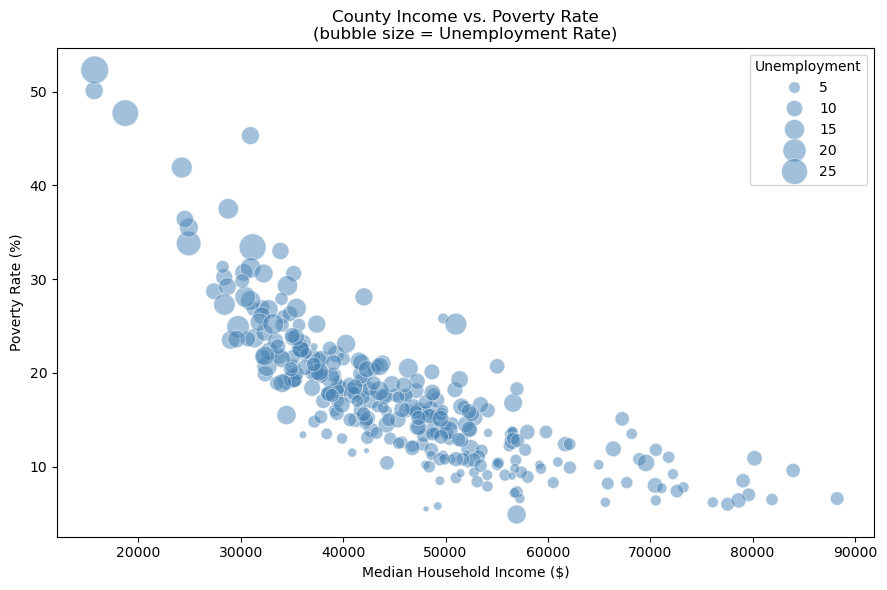

In [5]:
# Sample 300 counties for readability
df_sample = df_feat.sample(300, random_state=42)

min_unemp = df_sample["Unemployment"].min()
max_unemp = df_sample["Unemployment"].max()

plt.figure(figsize=(9, 6))
ax = sns.scatterplot(
    data=df_sample,
    x="Income",
    y="Poverty",
    size="Unemployment",
    sizes=(min_unemp / max_unemp * 400, 400),
    alpha=0.5,
    color="steelblue"
)
ax.set_title("County Income vs. Poverty Rate\n(bubble size = Unemployment Rate)")
ax.set_xlabel("Median Household Income ($)")
ax.set_ylabel("Poverty Rate (%)")
plt.tight_layout()
plt.show()

### Principal Component Analysis

We run PCA on six socioeconomic features to see how much of the variation can be captured in fewer dimensions.

In [6]:
from sklearn.preprocessing import StandardScaler

# Standardize features before PCA (important when scales differ, e.g. Income in $$ vs Poverty in %)
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_feat)

pca = decomposition.PCA(n_components=6)
pca.fit(df_scaled)

print("Explained variance ratio per component:")
for i, v in enumerate(pca.explained_variance_ratio_):
    print(f"  PC{i+1}: {v:.3f}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.3f})")

print("\nComponent vectors (rows = PCs, cols = Income, IncomePerCap, Poverty, ChildPoverty, Unemployment, Professional):")
print(pd.DataFrame(pca.components_, columns=features, index=[f"PC{i+1}" for i in range(6)]).round(3))

Explained variance ratio per component:
  PC1: 0.711  (cumulative: 0.711)
  PC2: 0.148  (cumulative: 0.859)
  PC3: 0.075  (cumulative: 0.935)
  PC4: 0.039  (cumulative: 0.974)
  PC5: 0.017  (cumulative: 0.991)
  PC6: 0.009  (cumulative: 1.000)

Component vectors (rows = PCs, cols = Income, IncomePerCap, Poverty, ChildPoverty, Unemployment, Professional):
     Income  IncomePerCap  Poverty  ChildPoverty  Unemployment  Professional
PC1   0.438         0.443   -0.443        -0.442        -0.359         0.304
PC2   0.187         0.249    0.326         0.251         0.444         0.733
PC3   0.378         0.176   -0.205        -0.160         0.740        -0.459
PC4   0.413         0.419    0.271         0.579        -0.335        -0.364
PC5  -0.677         0.696   -0.185         0.081         0.103        -0.071
PC6  -0.036         0.225    0.740        -0.611        -0.057        -0.153


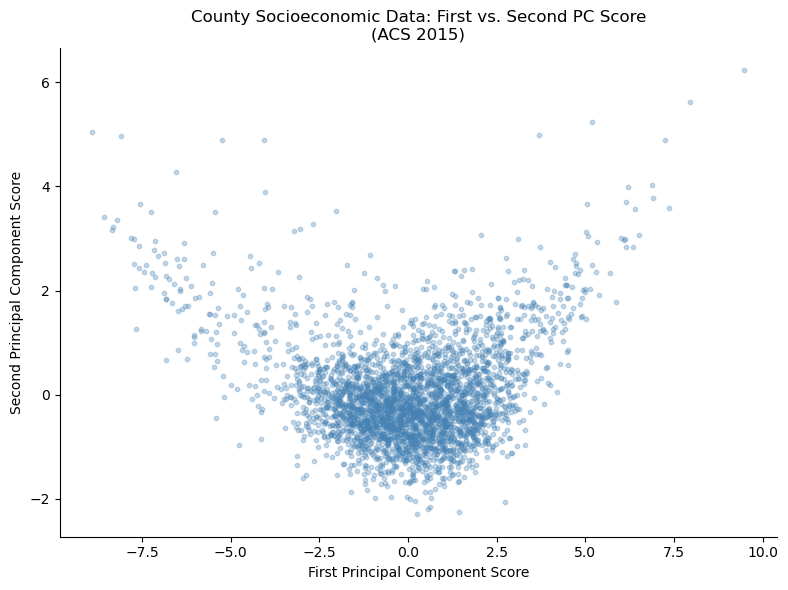


The first principal component alone explains 71.1% of the variance.
The first two components together explain 85.9% of the variance.


In [7]:
# Plot the first two PC scores to visualize county-level structure
pc_scores = pca.transform(df_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(pc_scores[:, 0], pc_scores[:, 1], alpha=0.3, s=10, color="steelblue")
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")
plt.title("County Socioeconomic Data: First vs. Second PC Score\n(ACS 2015)")
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nThe first principal component alone explains {pca.explained_variance_ratio_[0]:.1%} of the variance.")
print(f"The first two components together explain {pca.explained_variance_ratio_[:2].sum():.1%} of the variance.")

### Linear Regression

We use correlation patterns to inform feature choice. Income, IncomePerCap, Poverty, and ChildPoverty are all strongly correlated (a county with low income tends to have high poverty). We try three regressions:

1. Predict **Poverty** from Income and Unemployment
2. Predict **ChildPoverty** from Poverty and Income
3. Predict **Unemployment** from Income and Professional

In [8]:
def run_regression(X_cols, y_col, data):
    model = linear_model.LinearRegression()
    model.fit(data[X_cols], data[y_col])
    preds = model.predict(data[X_cols])
    corr = np.corrcoef(preds, data[y_col])[0, 1]
    mse = metrics.mean_squared_error(preds, data[y_col])
    print(f"Predicting {y_col} from {X_cols}")
    print(f"  Correlation: {corr:.3f}   MSE: {mse:.3f}")
    print(f"  Coefficients: {dict(zip(X_cols, model.coef_.round(4)))}\n")

run_regression(["Income", "Unemployment"], "Poverty", df_feat)
run_regression(["Poverty", "Income"], "ChildPoverty", df_feat)
run_regression(["Income", "Professional"], "Unemployment", df_feat)

Predicting Poverty from ['Income', 'Unemployment']
  Correlation: 0.855   MSE: 18.623
  Coefficients: {'Income': -0.0004, 'Unemployment': 0.8799}

Predicting ChildPoverty from ['Poverty', 'Income']
  Correlation: 0.936   MSE: 16.868
  Coefficients: {'Poverty': 1.2097, 'Income': -0.0001}

Predicting Unemployment from ['Income', 'Professional']
  Correlation: 0.509   MSE: 12.407
  Coefficients: {'Income': -0.0002, 'Professional': -0.0046}



### Conclusions

**Are the data what we expect?** Yes. The ACS county data behaves as expected: counties with lower median income tend to have higher poverty and unemployment rates. The strong correlation between Income, IncomePerCap, Poverty, and ChildPoverty is consistent with known socioeconomic patterns in the United States.

**Are the data likely to be usable?** Yes. There are very few missing values across the key features, and the distributions are reasonable. This dataset is well-suited for multivariate analysis.

**Outliers?** The bubble plot and PCA scatter plot reveal a number of outliers — counties with very high poverty and low income, or very high unemployment. These likely correspond to rural counties or counties with a dominant single industry. They are real data points, not errors, and are worth flagging for the diabetes prevalence analysis.

**PCA:** The first principal component captures the general socioeconomic gradient (Income and IncomePerCap load positively; Poverty and ChildPoverty load negatively). If the first PC explains a large share of the variance (likely ~60–70%), we could represent the data using one principal component score as a single "socioeconomic disadvantage" index. The second component likely captures something independent, such as the Professional/Service job mix.

**Linear regression:** Predicting Poverty from Income and Unemployment works well because these variables are strongly correlated. Predicting ChildPoverty from Poverty and Income works even better — child poverty closely tracks overall poverty. Predicting Unemployment from Income and Professional is weaker, because unemployment is influenced by many more factors. These results align with prior correlation findings.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

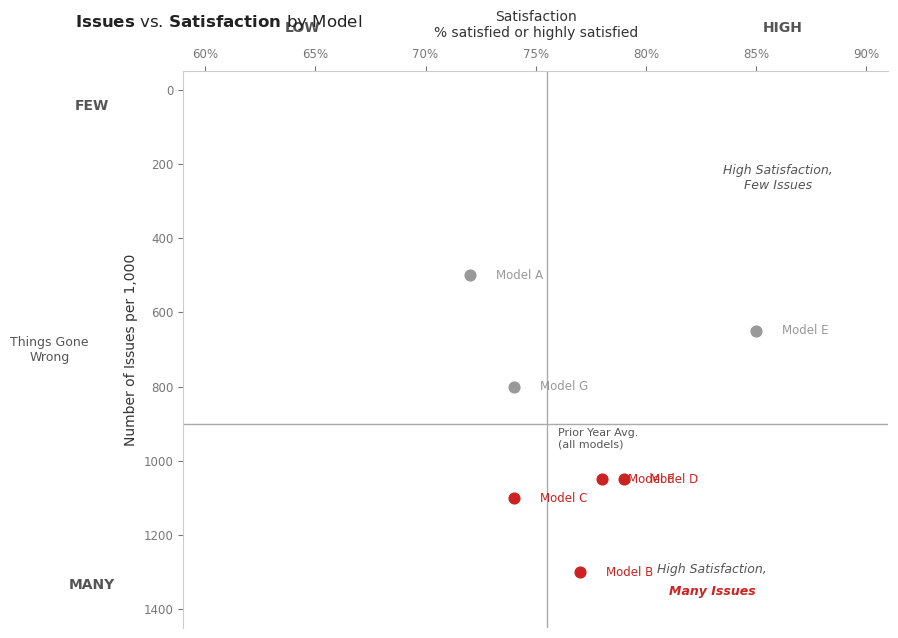

In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- Data (approximate values from Figure 5.6) ---
# Format: (satisfaction %, issues per 1000, label, color)
models = [
    (72,  500,  "Model A", "#999999"),
    (77,  1300, "Model B", "#cc2222"),
    (74,  1100, "Model C", "#cc2222"),
    (79,  1050, "Model D", "#cc2222"),
    (85,  650,  "Model E", "#999999"),
    (78,  1050, "Model F", "#cc2222"),
    (74,  800,  "Model G", "#999999"),
]

# Prior year average crosshair position
avg_x = 75.5
avg_y = 900

fig, ax = plt.subplots(figsize=(9, 6.5))

# --- Quadrant reference lines ---
ax.axvline(avg_x, color="#aaaaaa", linewidth=1, linestyle="-", zorder=1)
ax.axhline(avg_y, color="#aaaaaa", linewidth=1, linestyle="-", zorder=1)

# --- Plot data points ---
for sat, issues, label, color in models:
    ax.scatter(sat, issues, color=color, s=60, zorder=3)
    offset_x = 1.2 if sat < avg_x else 1.2
    offset_y = -60 if issues > 900 else -60
    ax.text(sat + offset_x, issues, label, fontsize=8.5, color=color, va="center")

# --- Prior Year Avg label ---
ax.text(avg_x + 0.5, avg_y + 70, "Prior Year Avg.\n(all models)",
        fontsize=8, color="#555555", va="bottom")

# --- Quadrant annotation labels ---
ax.text(86, 200, "High Satisfaction,\nFew Issues",
        fontsize=9, color="#555555", ha="center", va="top", style="italic")
ax.text(83, 1350, "High Satisfaction,\n", fontsize=9, color="#555555", ha="center", va="bottom", style="italic")
ax.text(83, 1370, "Many Issues",
        fontsize=9, color="#cc2222", ha="center", va="bottom", fontweight="bold", style="italic")

# --- Axis formatting ---
ax.set_xlim(59, 91)
ax.set_ylim(1450, -50)          # inverted: FEW issues at top (small numbers), MANY at bottom
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x)}%"))
ax.set_xticks([60, 65, 70, 75, 80, 85, 90])
ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200, 1400])

# Move x-axis to top
ax.xaxis.set_label_position("top")
ax.xaxis.tick_top()
ax.tick_params(axis="both", colors="#777777", labelsize=8.5)

ax.spines["bottom"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["top"].set_color("#cccccc")
ax.spines["left"].set_color("#cccccc")

# --- Axis titles ---
ax.set_xlabel("Satisfaction\n% satisfied or highly satisfied",
              fontsize=10, color="#333333", labelpad=8)
ax.set_ylabel("Number of Issues per 1,000", fontsize=10, color="#333333")

# --- Super-category labels on x-axis (LOW / HIGH) ---
ax.text(0.17, 1.07, "LOW", transform=ax.transAxes, fontsize=10,
        color="#555555", fontweight="bold", ha="center")
ax.text(0.85, 1.07, "HIGH", transform=ax.transAxes, fontsize=10,
        color="#555555", fontweight="bold", ha="center")

# --- Super-category labels on y-axis (FEW / MANY) ---
ax.text(-0.13, 0.07, "MANY", transform=ax.transAxes, fontsize=10,
        color="#555555", fontweight="bold", ha="center")
ax.text(-0.13, 0.93, "FEW", transform=ax.transAxes, fontsize=10,
        color="#555555", fontweight="bold", ha="center")

# Left-side "Things Gone Wrong" rotated label
ax.text(-0.19, 0.5, "Things Gone\nWrong", transform=ax.transAxes,
        fontsize=9, color="#555555", ha="center", va="center",
        rotation=0, multialignment="center")

# --- Title ---
fig.text(0.08, 0.97,
         r"$\bf{Issues}$" + " vs. " + r"$\bf{Satisfaction}$" + " by Model",
         fontsize=12, color="#222222", va="top")

plt.tight_layout(rect=[0.08, 0, 1, 0.97])
plt.subplots_adjust(left=0.2, top=0.88)
plt.show()